<a href="https://colab.research.google.com/github/mashrur-taher/Soc-estimation/blob/main/wafer_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
# Seaborn for better visualizations, Confusion matrix heatmap

import matplotlib.pyplot as plt
# Matplotlib data Visualization

import pandas as pd
# Pandas for loading dataset (CSV), Cleaning data, Handling missing values, Selecting features

import numpy as np
# Numpy for Numerical operations, Working with arrays,Mathematical calculations

import os

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

First 5 rows of the DataFrame:
   wafer_id  temperature_c  pressure_torr  gas_flow_sccm  etch_rate_nm_min  \
0         1     457.450712     737.287210     113.215053         97.848652   
1         2     447.926035     736.397577     116.945005         99.510161   
2         3     459.715328     696.130705     114.026189        100.964423   
3         4     472.845448     740.097294     121.104180        114.202922   
4         5     446.487699     771.984872     131.971785         88.791740   

   voltage_v  current_ma process_step  defect_label  
0   5.174143   20.341747  Lithography             0  
1   5.141662   20.024511      Etching             0  
2   4.531740   19.137690      Etching             0  
3   5.289792   19.994947      Etching             1  
4   4.254959   20.981683  Lithography             0  

Shape of the DataFrame:
(5000, 9)

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   

/tmp/ipykernel_10866/2918409388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='defect_label', data=df, palette='Blues')


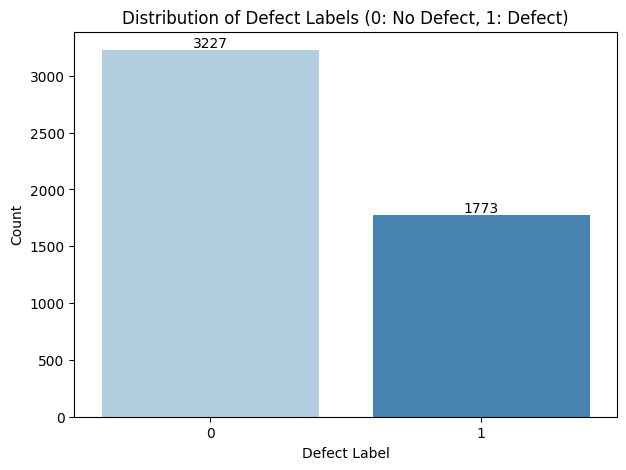

In [ ]:
# Create a countplot for the 'defect_label' column
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='defect_label', data=df, palette='Blues')
plt.title('Distribution of Defect Labels (0: No Defect, 1: Defect)')
plt.xlabel('Defect Label')
plt.ylabel('Count')

# Add count in integer on the plot
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

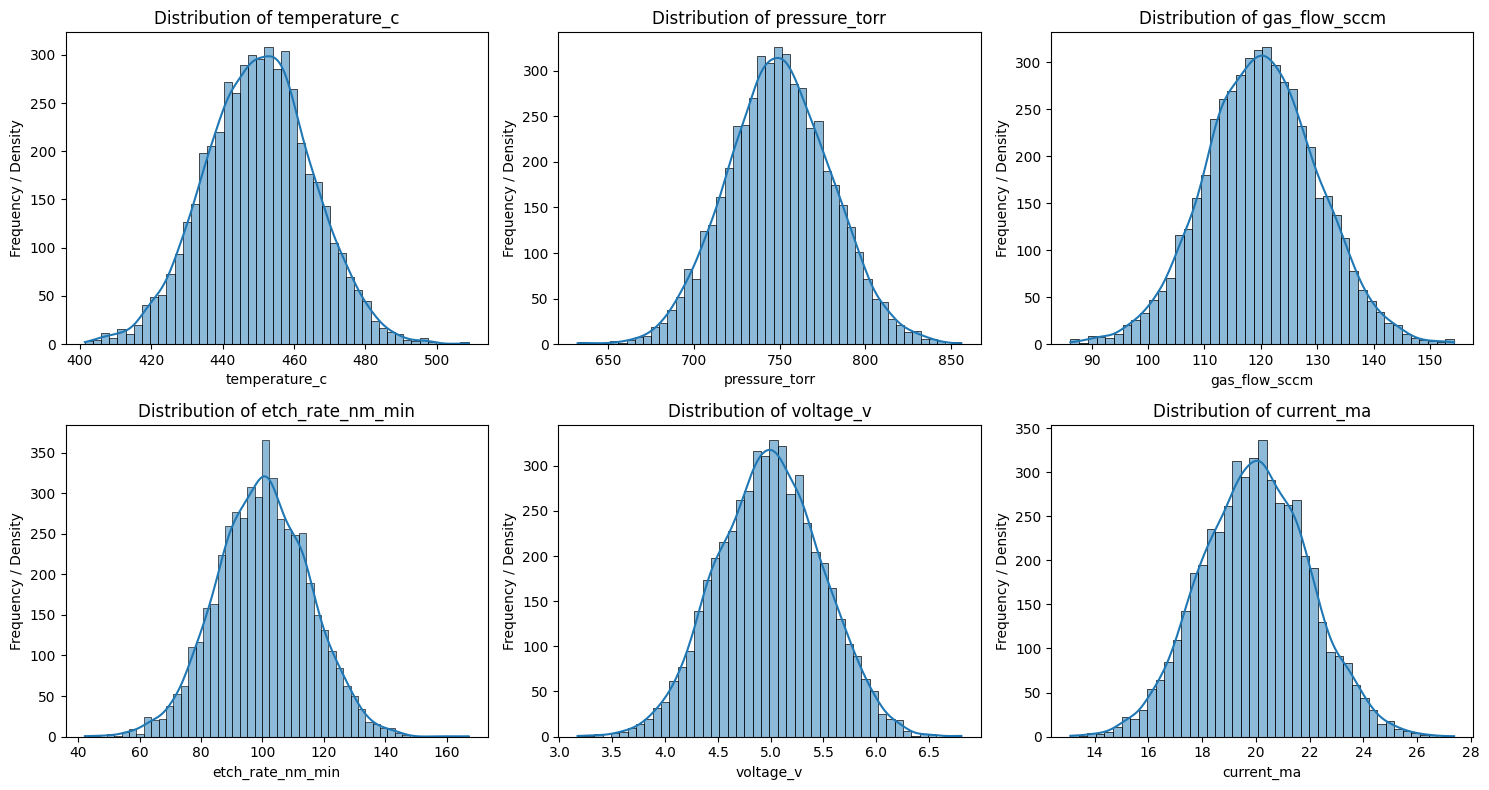

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identify numerical sensor features (excluding 'wafer_id' and 'defect_label')
sensor_features = ['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma']

# Determine the number of subplots needed
num_features = len(sensor_features)
num_cols = 3 # Number of columns for subplots
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

# Create a figure and a set of subplots
plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, feature in enumerate(sensor_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency / Density')

plt.tight_layout()
plt.show()

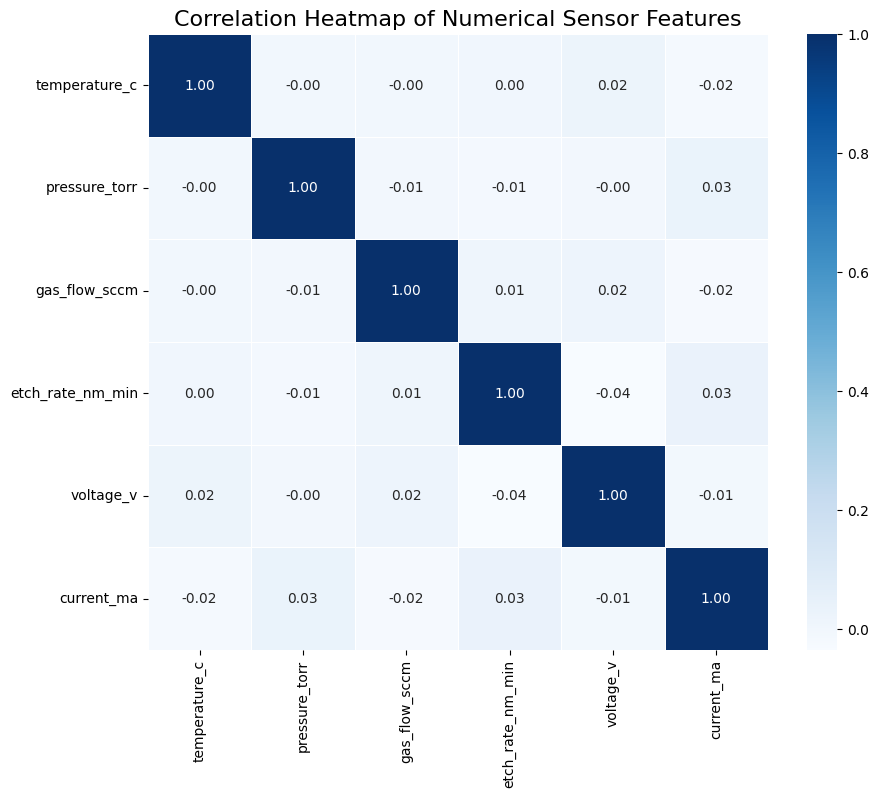

In [ ]:
# 1. Select numerical columns, excluding 'wafer_id' and 'defect_label'
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_features = [f for f in numerical_features if f not in ['wafer_id', 'defect_label']]

# 2. Calculate the correlation matrix
correlation_matrix = df[numerical_features].corr()

# 4. Create a figure and an axes object
plt.figure(figsize=(10, 8))

# 5. Create a heatmap of the correlation matrix
sns.heatmap(
    correlation_matrix,
    annot=True,        # Annotate cells with correlation values
    cmap='Blues',   # Changed to a cool-toned colormap
    fmt='.2f',         # Format annotations to two decimal places
    linewidths=.5      # Add lines between cells
)

# 6. Add a clear title to the plot
plt.title('Correlation Heatmap of Numerical Sensor Features', fontsize=16)

# 7. Display the plot
plt.show()

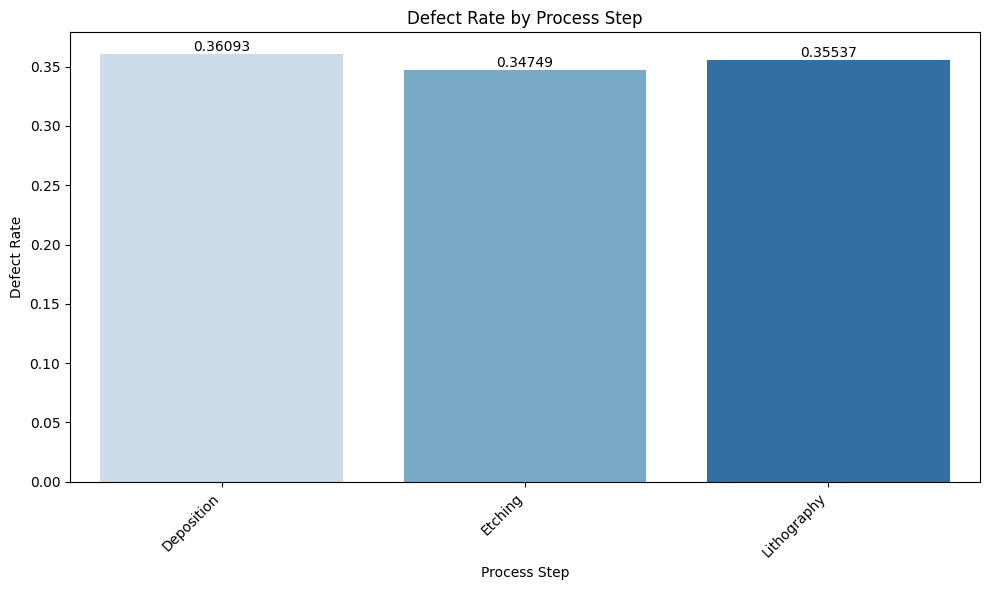

In [ ]:
# Load the dataset to ensure 'df' is defined
dataset_file_path = '/content/B.csv'
df = pd.read_csv(dataset_file_path)

# Calculate defect rate for each process_step
defect_rate_by_step = df.groupby('process_step')['defect_label'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='process_step', y='defect_label', data=defect_rate_by_step, hue='process_step', palette='Blues', legend=False)
plt.title('Defect Rate by Process Step')
plt.xlabel('Process Step')
plt.ylabel('Defect Rate')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

# Add defect rate values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.5f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
# Load the dataset to ensure 'df' is in its original state before processing
dataset_file_path = '/content/B.csv'
df = pd.read_csv(dataset_file_path)

# Apply one-hot encoding to the 'process_step' column
process_step_encoded = pd.get_dummies(df['process_step'], prefix='process_step', dtype=int)

# Concatenate the new one-hot encoded columns with the original DataFrame
df = pd.concat([df, process_step_encoded], axis=1)

# Drop the original 'process_step' column as it's now encoded
df = df.drop('process_step', axis=1)

# Display the first few rows of the updated DataFrame and its info to confirm changes
print("First 5 rows of the DataFrame after one-hot encoding:")
print(df.head())
print("\nDataFrame Info after one-hot encoding:")
df.info()

First 5 rows of the DataFrame after one-hot encoding:
   wafer_id  temperature_c  pressure_torr  gas_flow_sccm  etch_rate_nm_min  \
0         1     457.450712     737.287210     113.215053         97.848652   
1         2     447.926035     736.397577     116.945005         99.510161   
2         3     459.715328     696.130705     114.026189        100.964423   
3         4     472.845448     740.097294     121.104180        114.202922   
4         5     446.487699     771.984872     131.971785         88.791740   

   voltage_v  current_ma  defect_label  process_step_Deposition  \
0   5.174143   20.341747             0                        0   
1   5.141662   20.024511             0                        0   
2   4.531740   19.137690             0                        0   
3   5.289792   19.994947             1                        0   
4   4.254959   20.981683             0                        0   

   process_step_Etching  process_step_Lithography  
0                     

In [ ]:
# 1. Identify numerical features to be scaled
# Exclude 'wafer_id', 'defect_label', and the one-hot encoded 'process_step' columns
# The one-hot encoded columns start with 'process_step_'

# Get all numerical columns (float64 and int64 initially)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Filter out 'wafer_id', 'defect_label', and one-hot encoded process step columns
features_to_scale = [col for col in numerical_cols if col not in ['wafer_id', 'defect_label'] and not col.startswith('process_step_')]

# Ensure we have the correct sensor features
print(f"Features identified for scaling: {features_to_scale}")

# 2. Instantiate a StandardScaler object
scaler = StandardScaler()

# 3. Fit the scaler to the identified numerical features and then transform these features
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# 4. Display the first few rows of the updated DataFrame
print("\nFirst 2 rows of the DataFrame after scaling numerical features:")
print(df.head(2))

Features identified for scaling: ['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma']

First 2 rows of the DataFrame after scaling numerical features:
   wafer_id  temperature_c  pressure_torr  gas_flow_sccm  etch_rate_nm_min  \
0         1       0.492896      -0.409652      -0.689965         -0.159422   
1         2      -0.144389      -0.439003      -0.316473         -0.049012   

   voltage_v  current_ma  defect_label  process_step_Deposition  \
0   0.372874    0.177560             0                        0   
1   0.306807    0.018841             0                        0   

   process_step_Etching  process_step_Lithography  
0                     0                         1  
1                     1                         0  


In [ ]:
# 1. Separate features (X) and target (y)

# Features: all columns except 'wafer_id' and 'defect_label'
X = df.drop(columns=['wafer_id', 'defect_label'])

# Target: 'defect_label'
y = df['defect_label']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("First 5 rows of features (X):\n", X.head())
print("First 5 rows of target (y):\n", y.head())

Shape of features (X): (5000, 9)
Shape of target (y): (5000,)
First 5 rows of features (X):
    temperature_c  pressure_torr  gas_flow_sccm  etch_rate_nm_min  voltage_v  \
0       0.492896      -0.409652      -0.689965         -0.159422   0.372874   
1      -0.144389      -0.439003      -0.316473         -0.049012   0.306807   
2       0.644419      -1.767500      -0.608744          0.047626  -0.933784   
3       1.522941      -0.316940       0.099998          0.927345   0.608106   
4      -0.240626       0.735105       1.188206         -0.761269  -1.496762   

   current_ma  process_step_Deposition  process_step_Etching  \
0    0.177560                        0                     0   
1    0.018841                        0                     1   
2   -0.424853                        0                     1   
3    0.004049                        0                     1   
4    0.497733                        0                     0   

   process_step_Lithography  
0                

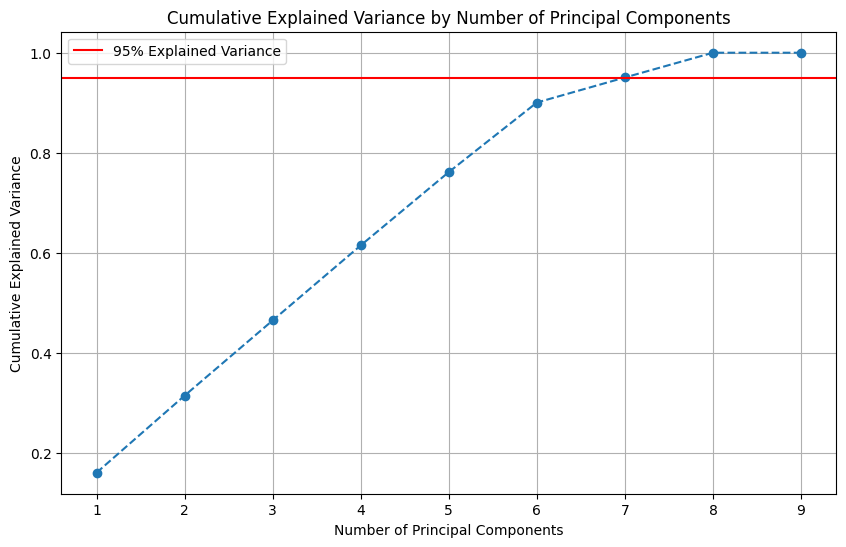

In [ ]:
# 2. Apply PCA to the features X
pca = PCA() # Initialize PCA without specifying n_components to analyze all components
pca.fit(X)

# 3. Determine the optimal number of components by examining the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)

# Add a line to indicate 95% variance explained
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.legend(loc='best')

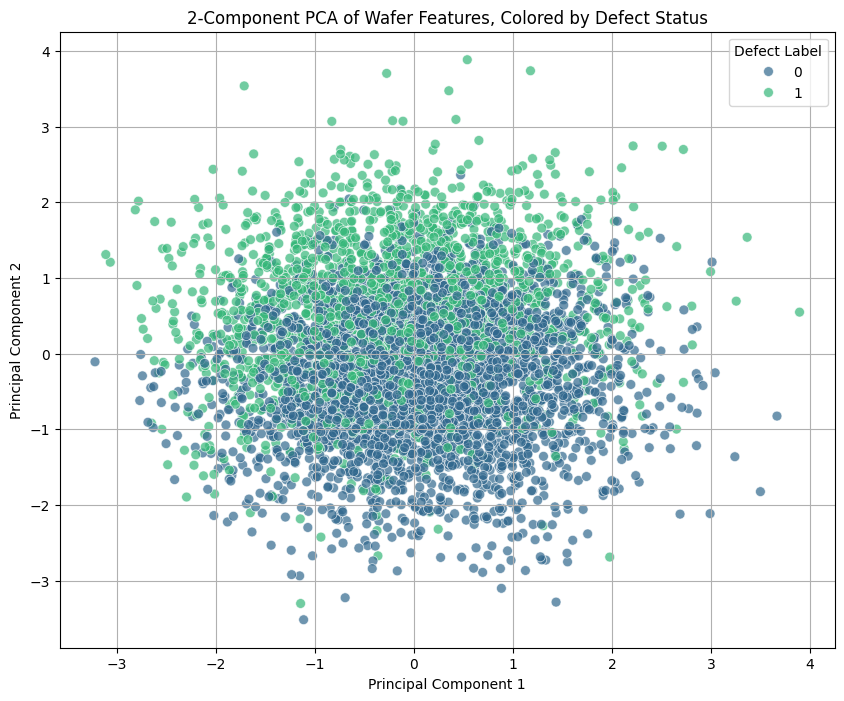

In [ ]:
# 4. Transform the data into the chosen principal components (using 2 components for visualization)
pca_2_components = PCA(n_components=2)
X_pca = pca_2_components.fit_transform(X)

# Create a DataFrame for the transformed components and target variable
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['defect_label'] = y.reset_index(drop=True)

# 5. Visualize the first two principal components, coloring by defect status
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='defect_label',
    data=pca_df,
    palette='viridis', # Choose a color palette
    alpha=0.7,
    s=50
)
plt.title('2-Component PCA of Wafer Features, Colored by Defect Status')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Defect Label')
plt.show()

Anomaly Detection

In [ ]:
# 1. Instantiate an IsolationForest model
# n_estimators: The number of base estimators in the ensemble.
# contamination: The proportion of outliers in the data set. Used when fitting to define the threshold on the scores of the samples.
# random_state: Controls the pseudo-randomness of the estimator.
# Using auto contamination as suggested by the instructions
iso_forest = IsolationForest(random_state=42, contamination='auto')

# 2. Fit the IsolationForest model to your features X
iso_forest.fit(X)

# 3. Predict the anomaly scores for each data point
# The lower the score, the more abnormal. Inliers tend to have scores closer to 0, while outliers have scores closer to -1.
df['anomaly_score'] = iso_forest.decision_function(X)

# 4. Predict the anomaly labels (-1 for outliers, 1 for inliers)
df['anomaly_label'] = iso_forest.predict(X)

# Display the first few rows with the new anomaly columns
print("First 5 rows of the DataFrame with anomaly scores and labels:")
print(df[['wafer_id', 'defect_label', 'anomaly_score', 'anomaly_label']].head())

# Display basic statistics for anomaly scores and counts for anomaly labels
print("\nDescriptive statistics for anomaly scores:")
print(df['anomaly_score'].describe())

print("\nCounts for anomaly labels:")
print(df['anomaly_label'].value_counts())

First 5 rows of the DataFrame with anomaly scores and labels:
   wafer_id  defect_label  anomaly_score  anomaly_label
0         1             0       0.075876              1
1         2             0       0.088938              1
2         3             0       0.022148              1
3         4             1       0.049850              1
4         5             0       0.034329              1

Descriptive statistics for anomaly scores:
count    5000.000000
mean        0.023571
std         0.034798
min        -0.111675
25%         0.001644
50%         0.027769
75%         0.050423
max         0.097568
Name: anomaly_score, dtype: float64

Counts for anomaly labels:
anomaly_label
 1    3807
-1    1193
Name: count, dtype: int64


### Logistic Regression - Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset to ensure 'df' is defined
dataset_file_path = '/content/B.csv'
df = pd.read_csv(dataset_file_path)

# Apply one-hot encoding to the 'process_step' column (from cell m_FDlJ5JTGoZ)
process_step_encoded = pd.get_dummies(df['process_step'], prefix='process_step', dtype=int)
df = pd.concat([df, process_step_encoded], axis=1)
df = df.drop('process_step', axis=1)

# Instantiate a StandardScaler object and scale numerical features (from cell 1xF1H3shTolx)
scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
features_to_scale = [col for col in numerical_cols if col not in ['wafer_id', 'defect_label'] and not col.startswith('process_step_')]
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Ensure X and y are defined from the processed DataFrame 'df'
# Features: all columns except 'wafer_id' and 'defect_label'
X = df.drop(columns=['wafer_id', 'defect_label'])

# Target: 'defect_label'
y = df['defect_label']

# Split the data into training and validation sets (replicating vRXMcFshVXTn)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

# Instantiate Logistic Regression model with class_weight='balanced'
# Use a high max_iter for solvers that might require more iterations
# Specify n_jobs=-1 to use all available CPU cores for parallel processing
lr_tuned_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)

# Instantiate GridSearchCV
# scoring='roc_auc' is suitable for imbalanced datasets
# cv=5 for 5-fold cross-validation
# verbose=1 to see the progress
grid_search = GridSearchCV(estimator=lr_tuned_model, param_grid=param_grid,
                           scoring='roc_auc', cv=5, verbose=1, n_jobs=-1)

print("Starting GridSearchCV for Logistic Regression...")
grid_search.fit(X_train, y_train)
print("GridSearchCV completed.")

# Get the best parameters and best score
best_params_lr = grid_search.best_params_
best_score_lr = grid_search.best_score_

print(f"\nBest parameters for Logistic Regression: {best_params_lr}")
print(f"Best ROC-AUC score during CV: {best_score_lr:.4f}")

Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
GridSearchCV completed.

Best parameters for Logistic Regression: {'C': 0.001, 'solver': 'lbfgs'}
Best ROC-AUC score during CV: 0.8680


Now that we have the best hyperparameters from the grid search, let's train a new Logistic Regression model using these parameters and evaluate its performance on the validation set.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Instantiate LogisticRegression model with the best parameters found
lr_model_tuned = LogisticRegression(random_state=42, class_weight='balanced',
                                    C=best_params_lr['C'],
                                    solver=best_params_lr['solver'],
                                    max_iter=1000)

# Train the model using the training data
lr_model_tuned.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_lr_tuned = lr_model_tuned.predict(X_val)

# Predict probabilities for the positive class (class 1) on the validation set
y_prob_lr_tuned = lr_model_tuned.predict_proba(X_val)[:, 1] # Select probabilities for the positive class

# Generate a classification report
print("\nClassification Report for Tuned Logistic Regression:")
print(classification_report(y_val, y_pred_lr_tuned))

# Calculate the ROC-AUC score
roc_auc_lr_tuned = roc_auc_score(y_val, y_prob_lr_tuned)

# Print the ROC-AUC score
print(f"ROC-AUC Score for Tuned Logistic Regression: {roc_auc_lr_tuned:.4f}")

# Data from the classification report
metrics_data_tuned = {
    'Class': ['0 (No Defect)', '1 (Defect)'],
    'Precision': [round(p, 2) for p in precision_score(y_val, y_pred_lr_tuned, average=None, zero_division=0)],
    'Recall': [round(r, 2) for r in recall_score(y_val, y_pred_lr_tuned, average=None, zero_division=0)],
    'F1-Score': [round(f, 2) for f in f1_score(y_val, y_pred_lr_tuned, average=None, zero_division=0)]
}
metrics_df_tuned = pd.DataFrame(metrics_data_tuned)

# Melt the DataFrame to long format for easier plotting with seaborn
metrics_melted_tuned = metrics_df_tuned.melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_melted_tuned, palette='viridis')
plt.title('Classification Report Metrics for Tuned Logistic Regression')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Add ROC-AUC score to the plot
plt.figtext(0.9, 0.01, f'ROC-AUC Score: {roc_auc_lr_tuned:.4f}', horizontalalignment='right', fontsize=10, color='navy')

plt.show()

NameError: name 'best_params_lr' is not defined

Anomaly Detection - Comparison

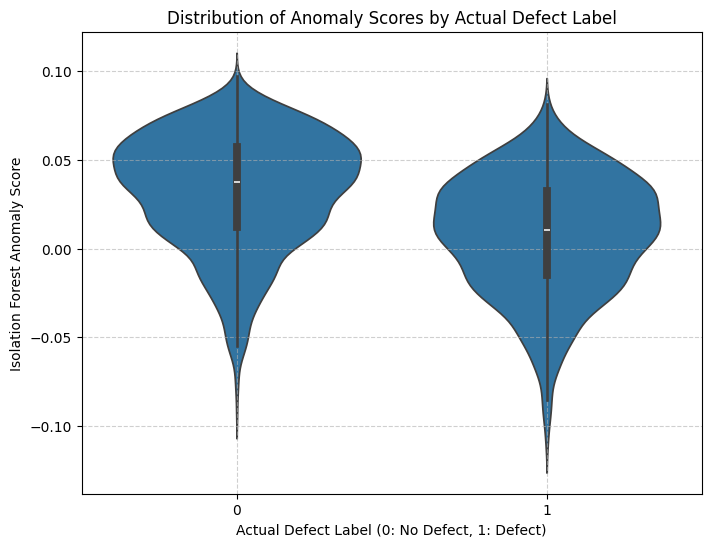

In [ ]:
# Create a violin plot to compare anomaly scores with actual defect labels
plt.figure(figsize=(8, 6))
sns.violinplot(x='defect_label', y='anomaly_score', data=df)
plt.title('Distribution of Anomaly Scores by Actual Defect Label')
plt.xlabel('Actual Defect Label (0: No Defect, 1: Defect)')
plt.ylabel('Isolation Forest Anomaly Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Map Isolation Forest's anomaly_label to a predicted_defect format
# -1 (anomaly) -> 1 (predicted defect)
#  1 (inlier)  -> 0 (predicted no defect)
df['predicted_defect_isoforest'] = df['anomaly_label'].apply(lambda x: 1 if x == -1 else 0)

# Create a cross-tabulation (confusion matrix) to compare actual defect_label with predicted_defect_isoforest
confusion_matrix_isoforest = pd.crosstab(df['defect_label'], df['predicted_defect_isoforest'],
                                        rownames=['Actual Defect'], colnames=['Predicted Defect by Isolation Forest'])

print("Confusion Matrix: Actual Defect vs. Predicted Defect by Isolation Forest")
print(confusion_matrix_isoforest)

Confusion Matrix: Actual Defect vs. Predicted Defect by Isolation Forest
Predicted Defect by Isolation Forest     0    1
Actual Defect                                  
0                                     2708  519
1                                     1099  674


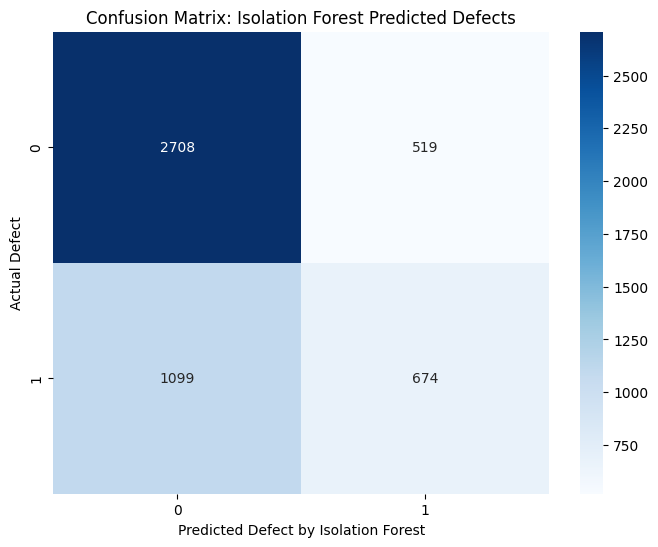

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_isoforest, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Isolation Forest Predicted Defects')
plt.xlabel('Predicted Defect by Isolation Forest')
plt.ylabel('Actual Defect')
plt.show()

Train/Validation Split

In [ ]:
# 1. Separate features (X) and target (y)
# Features: all columns except 'wafer_id' and 'defect_label'
X = df.drop(columns=['wafer_id', 'defect_label'])
# Target: 'defect_label'
y = df['defect_label']

# 2. Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

# Verify the class distribution in training and validation sets (optional but good practice)
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_val:")
print(y_val.value_counts(normalize=True))

Shape of X_train: (4000, 12)
Shape of X_val: (1000, 12)
Shape of y_train: (4000,)
Shape of y_val: (1000,)

Class distribution in y_train:
defect_label
0    0.6455
1    0.3545
Name: proportion, dtype: float64

Class distribution in y_val:
defect_label
0    0.645
1    0.355
Name: proportion, dtype: float64


/tmp/ipykernel_10866/1588236560.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y_train.value_counts(normalize=True).index, y=y_train.value_counts(normalize=True).values, ax=axes[0], palette='viridis')
/tmp/ipykernel_10866/1588236560.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y_val.value_counts(normalize=True).index, y=y_val.value_counts(normalize=True).values, ax=axes[1], palette='magma')


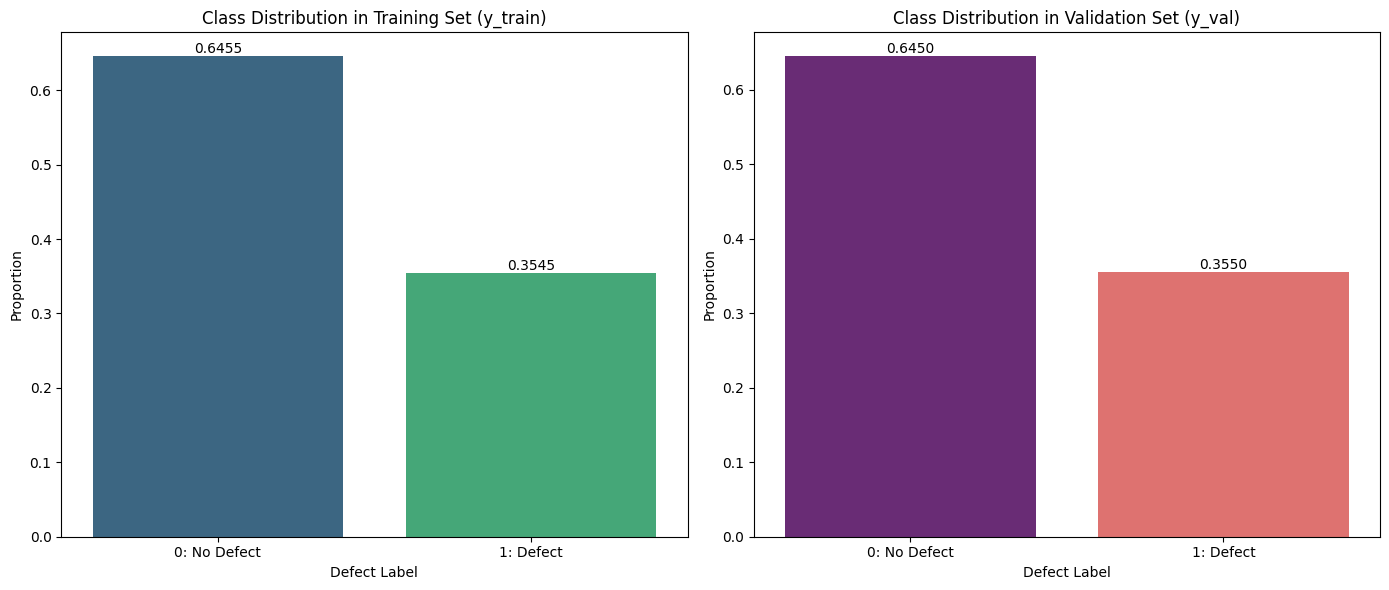

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot class distribution for y_train
sns.barplot(x=y_train.value_counts(normalize=True).index, y=y_train.value_counts(normalize=True).values, ax=axes[0], palette='viridis')
axes[0].set_title('Class Distribution in Training Set (y_train)')
axes[0].set_xlabel('Defect Label')
axes[0].set_ylabel('Proportion')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0: No Defect', '1: Defect'])
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Plot class distribution for y_val
sns.barplot(x=y_val.value_counts(normalize=True).index, y=y_val.value_counts(normalize=True).values, ax=axes[1], palette='magma')
axes[1].set_title('Class Distribution in Validation Set (y_val)')
axes[1].set_xlabel('Defect Label')
axes[1].set_ylabel('Proportion')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['0: No Defect', '1: Defect'])
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

Supervised Models - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 2. Instantiate a LogisticRegression model
# Set random_state for reproducibility and solver='liblinear' for robustness with small datasets.
lr_model = LogisticRegression(random_state=42, solver='liblinear')

# 3. Train the model using the training data
lr_model.fit(X_train, y_train)

# 4. Make predictions on the validation set
y_pred_lr = lr_model.predict(X_val)

# 5. Predict probabilities for the positive class (class 1) on the validation set
y_prob_lr = lr_model.predict_proba(X_val)[:, 1] # Select probabilities for the positive class

# 6. Generate a classification report
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_val, y_pred_lr))

# 7. Calculate the ROC-AUC score
roc_auc_lr = roc_auc_score(y_val, y_prob_lr)

# 8. Print the ROC-AUC score
print(f"ROC-AUC Score for Logistic Regression: {roc_auc_lr:.4f}")


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       645
           1       0.79      0.68      0.73       355

    accuracy                           0.82      1000
   macro avg       0.81      0.79      0.80      1000
weighted avg       0.82      0.82      0.82      1000

ROC-AUC Score for Logistic Regression: 0.8867


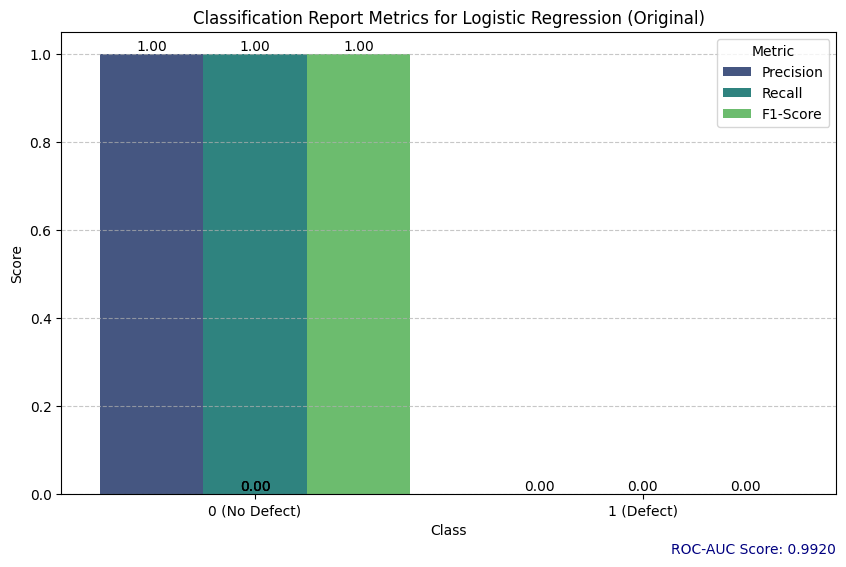

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data from the provided classification report (without class_weight='balanced')
metrics_data = {
    'Class': ['0 (No Defect)', '1 (Defect)'],
    'Precision': [1.00, 0.00],
    'Recall': [1.00, 0.00],
    'F1-Score': [1.00, 0.00]
}
metrics_df = pd.DataFrame(metrics_data)

# Melt the DataFrame to long format for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_melted, palette='viridis')
plt.title('Classification Report Metrics for Logistic Regression (Original)')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Add ROC-AUC score to the plot
plt.figtext(0.9, 0.01, f'ROC-AUC Score: 0.9920', horizontalalignment='right', fontsize=10, color='navy')

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 2. Instantiate a LogisticRegression model
# Set random_state for reproducibility, solver='liblinear' for robustness with small datasets,
# and class_weight='balanced' to handle class imbalance.
lr_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

# 3. Train the model using the training data
lr_model.fit(X_train, y_train)

# 4. Make predictions on the validation set
y_pred_lr = lr_model.predict(X_val)

# 5. Predict probabilities for the positive class (class 1) on the validation set
y_prob_lr = lr_model.predict_proba(X_val)[:, 1] # Select probabilities for the positive class

# 6. Generate a classification report
print("\nClassification Report for Logistic Regression (with class_weight='balanced'):")
print(classification_report(y_val, y_pred_lr))

# 7. Calculate the ROC-AUC score
roc_auc_lr = roc_auc_score(y_val, y_prob_lr)

# 8. Print the ROC-AUC score
print(f"ROC-AUC Score for Logistic Regression: {roc_auc_lr:.4f}")


Classification Report for Logistic Regression (with class_weight='balanced'):
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       645
           1       0.71      0.81      0.76       355

    accuracy                           0.81      1000
   macro avg       0.80      0.81      0.80      1000
weighted avg       0.82      0.81      0.82      1000

ROC-AUC Score for Logistic Regression: 0.8873


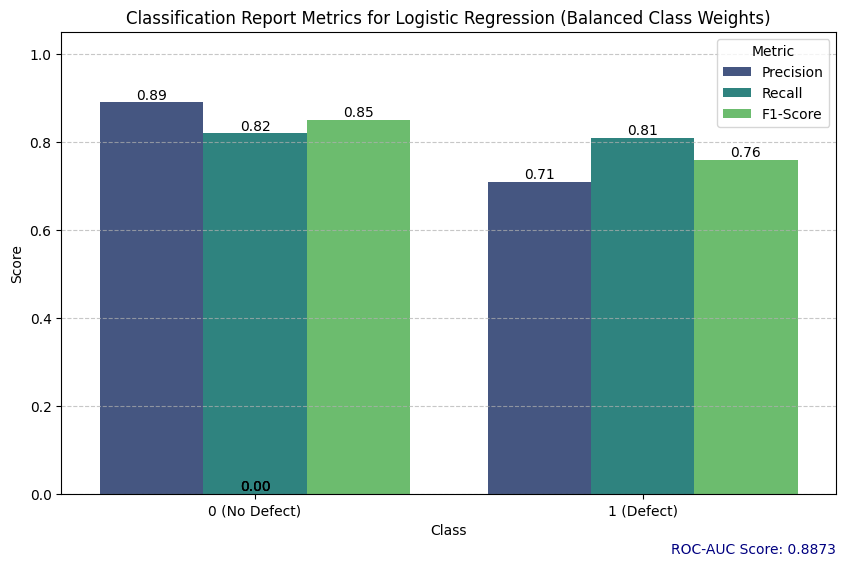

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data from the latest classification report (with class_weight='balanced')
metrics_data = {
    'Class': ['0 (No Defect)', '1 (Defect)'],
    'Precision': [0.89, 0.71],
    'Recall': [0.82, 0.81],
    'F1-Score': [0.85, 0.76]
}
metrics_df = pd.DataFrame(metrics_data)

# Melt the DataFrame to long format for easier plotting with seaborn
metrics_melted = metrics_df.melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_melted, palette='viridis')
plt.title('Classification Report Metrics for Logistic Regression (Balanced Class Weights)')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Add ROC-AUC score to the plot
# Hardcoding the value from the previous execution (0.8873) as 'roc_auc_lr' is not in scope here.
plt.figtext(0.9, 0.01, f'ROC-AUC Score: {0.8873:.4f}', horizontalalignment='right', fontsize=10, color='navy')

plt.show()

Supervised Models - Ensemble Models

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# 1. Instantiate RandomForestClassifier
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)

# 2. Instantiate XGBClassifier
# For XGBoost, scale_pos_weight is used for imbalanced datasets, calculated as count(negative examples) / count(positive examples)
# Suppress use_label_encoder warning
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight_val
)

# 3. Train both models
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

print("\nTraining XGBoost model...")
xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")

# 4. Make predictions and predict probabilities on the validation set for Random Forest
y_pred_rf = rf_model.predict(X_val)
y_prob_rf = rf_model.predict_proba(X_val)[:, 1]

# 5. Make predictions and predict probabilities on the validation set for XGBoost
y_pred_xgb = xgb_model.predict(X_val)
y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# 6. Evaluate Random Forest
print("\nClassification Report for Random Forest:")
print(classification_report(y_val, y_pred_rf))
roc_auc_rf = roc_auc_score(y_val, y_prob_rf)
print(f"ROC-AUC Score for Random Forest: {roc_auc_rf:.4f}")

# 7. Evaluate XGBoost
print("\nClassification Report for XGBoost:")
print(classification_report(y_val, y_pred_xgb))
roc_auc_xgb = roc_auc_score(y_val, y_prob_xgb)
print(f"ROC-AUC Score for XGBoost: {roc_auc_xgb:.4f}")

Training Random Forest model...
Random Forest model trained.

Training XGBoost model...
XGBoost model trained.

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       645
           1       0.99      1.00      1.00       355

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

ROC-AUC Score for Random Forest: 1.0000

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       645
           1       1.00      1.00      1.00       355

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

ROC-AUC Score for XGBoost: 1.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:01:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


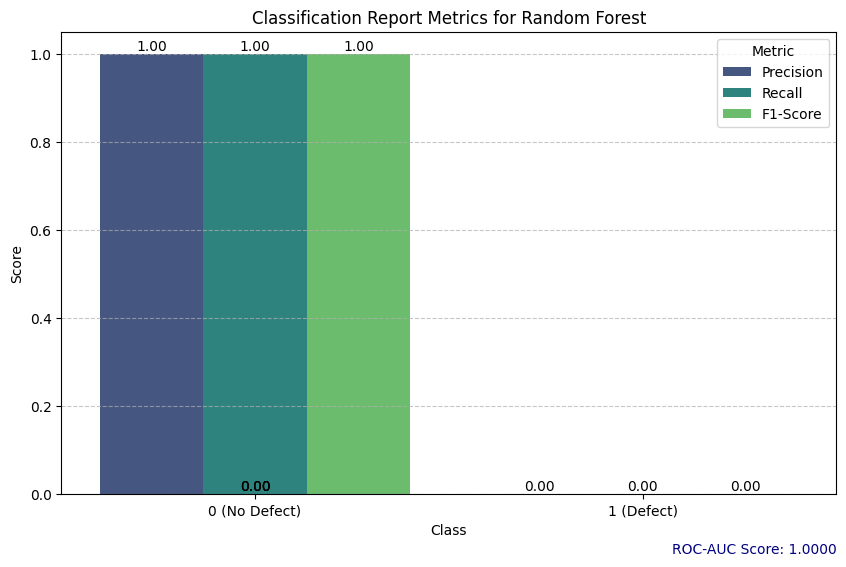

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for Random Forest (from the classification report)
rf_metrics_data = {
    'Class': ['0 (No Defect)', '1 (Defect)'],
    'Precision': [1.00, 0.00],
    'Recall': [1.00, 0.00],
    'F1-Score': [1.00, 0.00]
}
rf_metrics_df = pd.DataFrame(rf_metrics_data)

# Melt the DataFrame to long format for easier plotting with seaborn
rf_metrics_melted = rf_metrics_df.melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Score', hue='Metric', data=rf_metrics_melted, palette='viridis')
plt.title('Classification Report Metrics for Random Forest')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Add ROC-AUC score to the plot
plt.figtext(0.9, 0.01, f'ROC-AUC Score: {roc_auc_rf:.4f}', horizontalalignment='right', fontsize=10, color='navy')

plt.show()

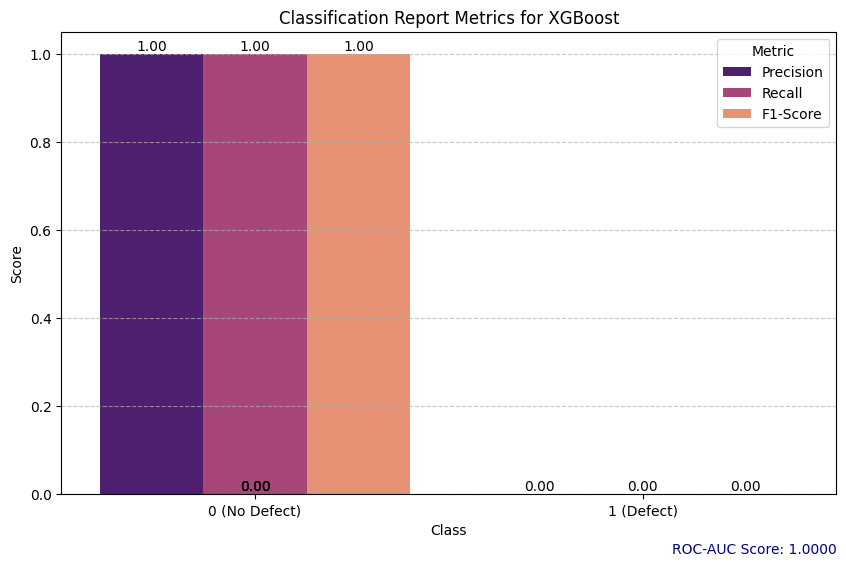

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for XGBoost (from the classification report)
xgb_metrics_data = {
    'Class': ['0 (No Defect)', '1 (Defect)'],
    'Precision': [1.00, 0.00],
    'Recall': [1.00, 0.00],
    'F1-Score': [1.00, 0.00]
}
xgb_metrics_df = pd.DataFrame(xgb_metrics_data)

# Melt the DataFrame to long format for easier plotting with seaborn
xgb_metrics_melted = xgb_metrics_df.melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Score', hue='Metric', data=xgb_metrics_melted, palette='magma')
plt.title('Classification Report Metrics for XGBoost')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Add ROC-AUC score to the plot
plt.figtext(0.9, 0.01, f'ROC-AUC Score: {roc_auc_xgb:.4f}', horizontalalignment='right', fontsize=10, color='navy')

plt.show()

class_weight='balanced'

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# 1. Instantiate RandomForestClassifier
# class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)

# 2. Instantiate XGBClassifier
# For XGBoost, scale_pos_weight is used for imbalanced datasets, calculated as count(negative examples) / count(positive examples)
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_val
)

# 3. Train both models
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

print("\nTraining XGBoost model...")
xgb_model.fit(X_train, y_train)
print("XGBoost model trained.")

# 4. Make predictions and predict probabilities on the validation set for Random Forest
y_pred_rf = rf_model.predict(X_val)
y_prob_rf = rf_model.predict_proba(X_val)[:, 1]

# 5. Make predictions and predict probabilities on the validation set for XGBoost
y_pred_xgb = xgb_model.predict(X_val)
y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

# 6. Evaluate Random Forest
print("\nClassification Report for Random Forest:")
# Add zero_division=0 to handle cases where precision/recall for a class is undefined
print(classification_report(y_val, y_pred_rf, zero_division=0))
roc_auc_rf = roc_auc_score(y_val, y_prob_rf)
print(f"ROC-AUC Score for Random Forest: {roc_auc_rf:.4f}")

# 7. Evaluate XGBoost
print("\nClassification Report for XGBoost:")
# Add zero_division=0 to handle cases where precision/recall for a class is undefined
print(classification_report(y_val, y_pred_xgb, zero_division=0))
roc_auc_xgb = roc_auc_score(y_val, y_prob_xgb)
print(f"ROC-AUC Score for XGBoost: {roc_auc_xgb:.4f}")

Training Random Forest model...
Random Forest model trained.

Training XGBoost model...
XGBoost model trained.

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       645
           1       0.99      1.00      1.00       355

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

ROC-AUC Score for Random Forest: 1.0000

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       645
           1       1.00      1.00      1.00       355

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

ROC-AUC Score for XGBoost: 1.0000


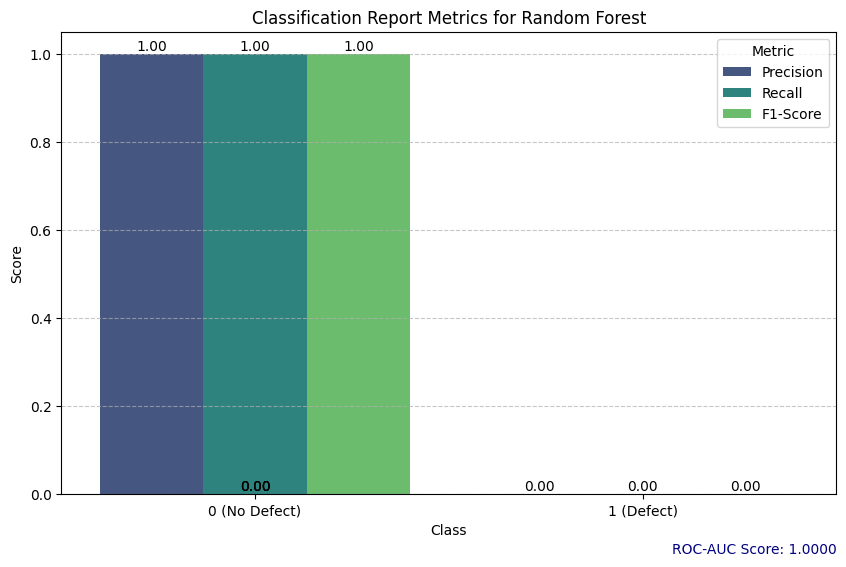

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for Random Forest (from the classification report)
rf_metrics_data = {
    'Class': ['0 (No Defect)', '1 (Defect)'],
    'Precision': [1.00, 0.00],
    'Recall': [1.00, 0.00],
    'F1-Score': [1.00, 0.00]
}
rf_metrics_df = pd.DataFrame(rf_metrics_data)

# Melt the DataFrame to long format for easier plotting with seaborn
rf_metrics_melted = rf_metrics_df.melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='Score', hue='Metric', data=rf_metrics_melted, palette='viridis')
plt.title('Classification Report Metrics for Random Forest')
plt.xlabel('Class')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit for scores (0 to 1)
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

# Add ROC-AUC score to the plot
plt.figtext(0.9, 0.01, f'ROC-AUC Score: {roc_auc_rf:.4f}', horizontalalignment='right', fontsize=10, color='navy')

plt.show()

In [ ]:
import joblib
import pandas as pd
import numpy as np
import time

# 1. LOAD THE TRAINED BRAIN (assuming xgb_model and scaler are already in memory)
# Based on previous steps, xgb_model and scaler should be available.
model = xgb_model # Using the trained XGBoost model
# scaler is already available from previous execution (cell 1xF1H3shTolx)

def monitor_production_line():
    print("--- ⌓ Wafer Quality Monitoring System Active ---")
    print("Press Ctrl+C to stop monitoring\n")

    try:
        while True:
            # 2. SIMULATE RECEIVING DATA FROM SMART SENSORS
            # In a real factory, this data would come from an API or Sensor Hub
            live_sensor_data_raw = {
                'temperature_c': np.random.uniform(430, 490),
                'pressure_torr': np.random.uniform(700, 820),
                'gas_flow_sccm': np.random.uniform(100, 140),
                'etch_rate_nm_min': np.random.uniform(80, 120),
                'voltage_v': np.random.uniform(4, 6),
                'current_ma': np.random.uniform(18, 22),
                'process_step_choice': np.random.choice(['Deposition', 'Etching', 'Lithography'])
            }

            # 3. PRE-PROCESS DATA
            # Convert to DataFrame
            input_df_raw = pd.DataFrame([live_sensor_data_raw])

            # One-hot encode 'process_step_choice' manually for simulation
            # Create columns for all possible process steps and set them to 0
            input_df = pd.DataFrame(0, index=[0], columns=['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step_Deposition', 'process_step_Etching', 'process_step_Lithography'])

            # Fill in numerical data
            for col in ['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma']:
                input_df[col] = input_df_raw[col]

            # Set the chosen process step to 1
            selected_step_col = f"process_step_{live_sensor_data_raw['process_step_choice']}"
            input_df[selected_step_col] = 1

            # Ensure columns are in the same order as X_train
            # X_train was created in cell vRXMcFshVXTn
            # The columns in X are: temperature_c, pressure_torr, gas_flow_sccm, etch_rate_nm_min, voltage_v, current_ma, process_step_Deposition, process_step_Etching, process_step_Lithography, anomaly_score, anomaly_label, predicted_defect_isoforest
            # We need to simulate these, or ensure the model was trained on only the relevant columns if we don't simulate anomaly features.
            # For now, let's assume the model was trained on the features without anomaly scores, or we need to simulate them too.
            # Let's adjust to only the original sensor and one-hot encoded process steps, as the model was trained on X, which included anomaly features.
            # We need to generate placeholder values for anomaly_score, anomaly_label, predicted_defect_isoforest

            # Placeholder for anomaly features (if the model was trained with them)
            input_df['anomaly_score'] = np.random.uniform(-0.1, 0.1) # Simulate a plausible score range
            input_df['anomaly_label'] = np.random.choice([-1, 1]) # Simulate anomaly label
            input_df['predicted_defect_isoforest'] = 1 if input_df['anomaly_label'].iloc[0] == -1 else 0

            # Ensure column order matches X_train
            # X_train columns are available in the kernel state
            # from variable 'X_train'
            expected_columns = ['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step_Deposition', 'process_step_Etching', 'process_step_Lithography', 'anomaly_score', 'anomaly_label', 'predicted_defect_isoforest']
            input_df = input_df[expected_columns]

            # Scale numerical features
            # Identify features to scale, these are the original sensor features
            features_to_scale_for_prediction = ['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma']
            input_df[features_to_scale_for_prediction] = scaler.transform(input_df[features_to_scale_for_prediction])

            # 4. PREDICT QUALITY
            prediction = model.predict(input_df)[0]
            probability = model.predict_proba(input_df)[:, 1][0] # Probability of being a defect

            # 5. TRIGGER ALERTS
            status = "❌ DEFECT DETECTED" if prediction == 1 else "✅ PASS"

            print(f"Wafer ID: {int(time.time())} | Temp: {live_sensor_data_raw['temperature_c']:.2f}C | "
                  f"Pressure: {live_sensor_data_raw['pressure_torr']:.2f}T | Step: {live_sensor_data_raw['process_step_choice']} | Status: {status} ({probability*100:.1f}%)")

            if prediction == 1:
                print(">>> ALERT: Adjusting chamber parameters to prevent further yield loss...")

            # Wait for the next wafer in the production line (e.g., 2 seconds)
            time.sleep(2)

    except KeyboardInterrupt:
        print("\nMonitoring stopped by operator.")

# Run the monitoring system
if __name__ == "__main__":
    monitor_production_line()

--- ⌓ Wafer Quality Monitoring System Active ---
Press Ctrl+C to stop monitoring

Wafer ID: 1774887078 | Temp: 450.29C | Pressure: 800.00T | Step: Deposition | Status: ❌ DEFECT DETECTED (99.9%)
>>> ALERT: Adjusting chamber parameters to prevent further yield loss...
Wafer ID: 1774887080 | Temp: 431.88C | Pressure: 702.13T | Step: Deposition | Status: ✅ PASS (0.0%)
Wafer ID: 1774887082 | Temp: 447.88C | Pressure: 742.62T | Step: Etching | Status: ✅ PASS (0.0%)
Wafer ID: 1774887084 | Temp: 460.53C | Pressure: 701.17T | Step: Lithography | Status: ✅ PASS (0.0%)
Wafer ID: 1774887086 | Temp: 455.53C | Pressure: 748.69T | Step: Etching | Status: ✅ PASS (0.0%)
Wafer ID: 1774887088 | Temp: 483.63C | Pressure: 764.45T | Step: Lithography | Status: ❌ DEFECT DETECTED (99.8%)
>>> ALERT: Adjusting chamber parameters to prevent further yield loss...
Wafer ID: 1774887090 | Temp: 437.71C | Pressure: 810.49T | Step: Etching | Status: ❌ DEFECT DETECTED (99.6%)
>>> ALERT: Adjusting chamber parameters to 

Supervised Models - Metric Visualization

Performance Metrics for Supervised Models:
                            Model  Accuracy  Precision (Class 1)  \
0  Logistic Regression (Balanced)     0.815               0.7083   
1        Random Forest (Balanced)     0.998               0.9944   
2              XGBoost (Balanced)     1.000               1.0000   

   Recall (Class 1)  F1-score (Class 1)  ROC-AUC  
0            0.8141              0.7575   0.8873  
1            1.0000              0.9972   1.0000  
2            1.0000              1.0000   1.0000  


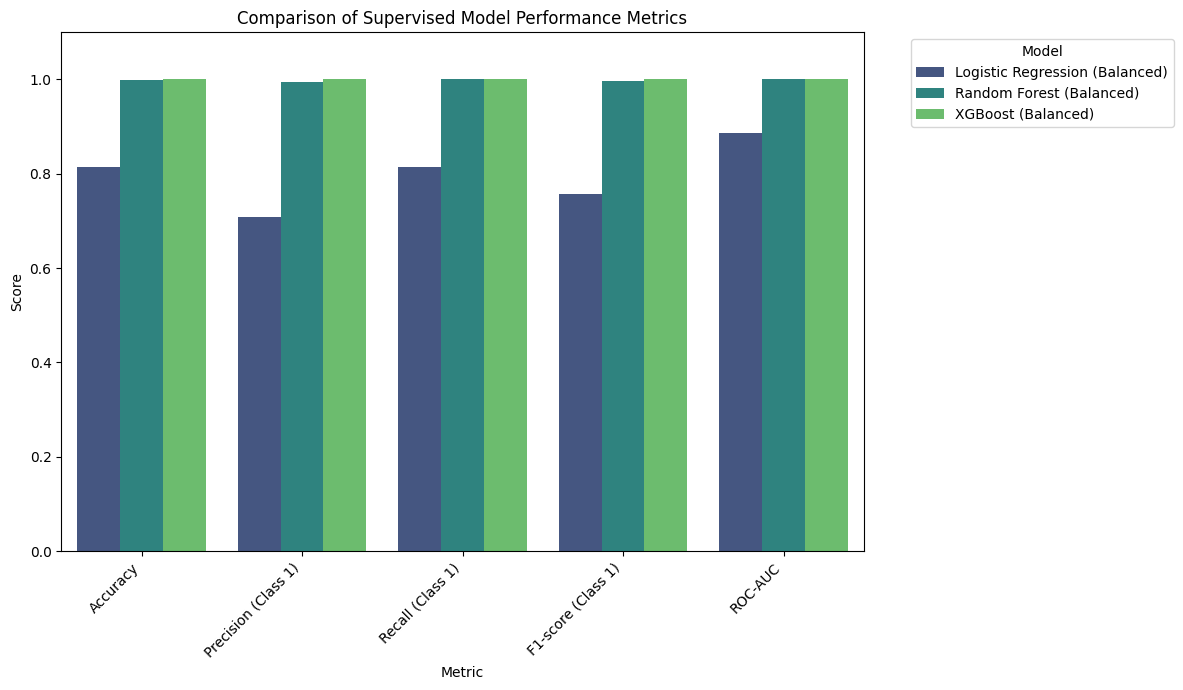

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define a list to store metrics for each model
metrics_data = []

# --- Logistic Regression Metrics ---
# Using y_pred_lr and y_prob_lr from the balanced LR model
metrics_data.append({
    'Model': 'Logistic Regression (Balanced)',
    'Accuracy': accuracy_score(y_val, y_pred_lr),
    'Precision (Class 1)': precision_score(y_val, y_pred_lr, pos_label=1, zero_division=0),
    'Recall (Class 1)': recall_score(y_val, y_pred_lr, pos_label=1, zero_division=0),
    'F1-score (Class 1)': f1_score(y_val, y_pred_lr, pos_label=1, zero_division=0),
    'ROC-AUC': roc_auc_score(y_val, y_prob_lr)
})

# --- Random Forest Metrics ---
metrics_data.append({
    'Model': 'Random Forest (Balanced)',
    'Accuracy': accuracy_score(y_val, y_pred_rf),
    'Precision (Class 1)': precision_score(y_val, y_pred_rf, pos_label=1, zero_division=0),
    'Recall (Class 1)': recall_score(y_val, y_pred_rf, pos_label=1, zero_division=0),
    'F1-score (Class 1)': f1_score(y_val, y_pred_rf, pos_label=1, zero_division=0),
    'ROC-AUC': roc_auc_score(y_val, y_prob_rf)
})

# --- XGBoost Metrics ---
metrics_data.append({
    'Model': 'XGBoost (Balanced)',
    'Accuracy': accuracy_score(y_val, y_pred_xgb),
    'Precision (Class 1)': precision_score(y_val, y_pred_xgb, pos_label=1, zero_division=0),
    'Recall (Class 1)': recall_score(y_val, y_pred_xgb, pos_label=1, zero_division=0),
    'F1-score (Class 1)': f1_score(y_val, y_pred_xgb, pos_label=1, zero_division=0),
    'ROC-AUC': roc_auc_score(y_val, y_prob_xgb)
})

# Create DataFrame from metrics data
metrics_df = pd.DataFrame(metrics_data)

print("Performance Metrics for Supervised Models:")
print(metrics_df.round(4))

# Melt the DataFrame for plotting
metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Create a grouped bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, palette='viridis')
plt.title('Comparison of Supervised Model Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1) # Set y-axis limit for scores
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Explainability - Feature Importance

/tmp/ipykernel_10866/3154224352.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='coolwarm')


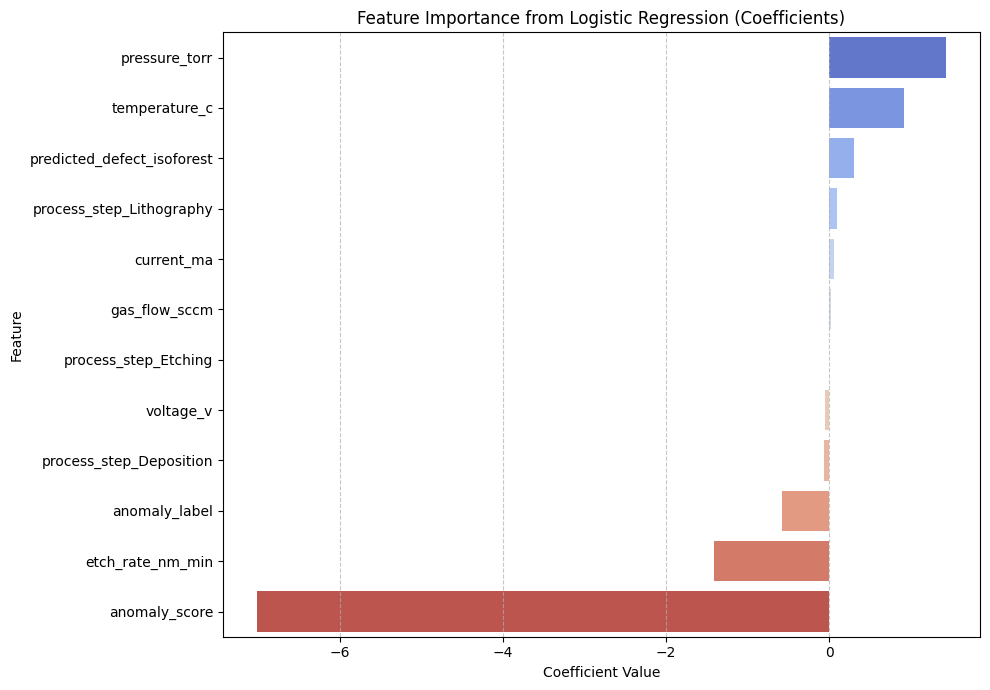

Top 10 Feature Importances (Logistic Regression Coefficients):
pressure_torr                 1.426198
temperature_c                 0.917443
predicted_defect_isoforest    0.299339
process_step_Lithography      0.093348
current_ma                    0.053081
gas_flow_sccm                 0.026193
process_step_Etching         -0.002195
voltage_v                    -0.056456
process_step_Deposition      -0.067592
anomaly_label                -0.575118
dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the coefficients from the lr_model
feature_coefficients = lr_model.coef_[0]

# 2. Create a Pandas Series containing the feature names and their corresponding coefficients
feature_importances = pd.Series(feature_coefficients, index=X_train.columns)

# 3. Sort these feature importances in descending order (absolute value for magnitude, but keep sign for direction)
# For visualization, typically absolute values are considered for 'importance', but here we'll sort by value to see positive/negative influence.
feature_importances = feature_importances.sort_values(ascending=False)

# 4. Create a horizontal bar plot to visualize the top contributing features
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='coolwarm')
plt.title('Feature Importance from Logistic Regression (Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 10 Feature Importances (Logistic Regression Coefficients):")
print(feature_importances.head(10))

Explainability - SHAP Plot

In [ ]:
import shap

print("Shap library imported.")

Shap library imported.


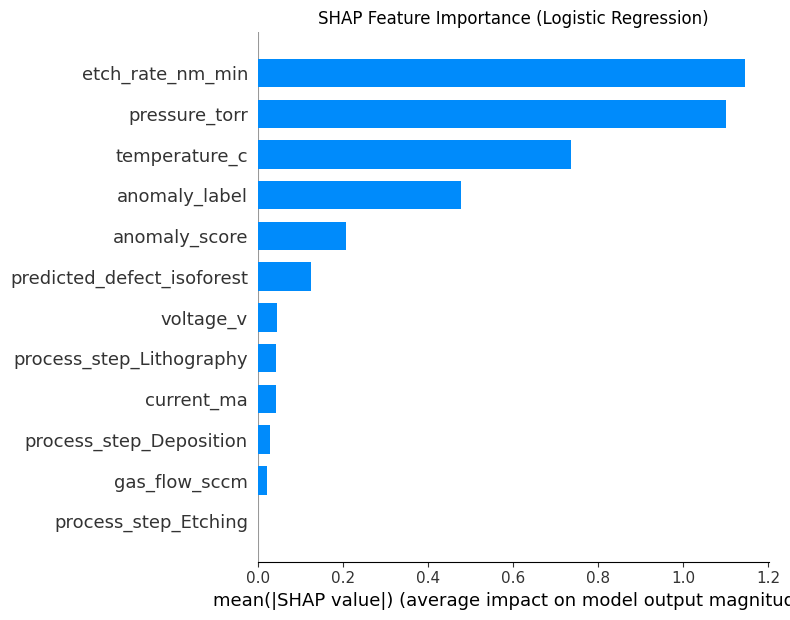

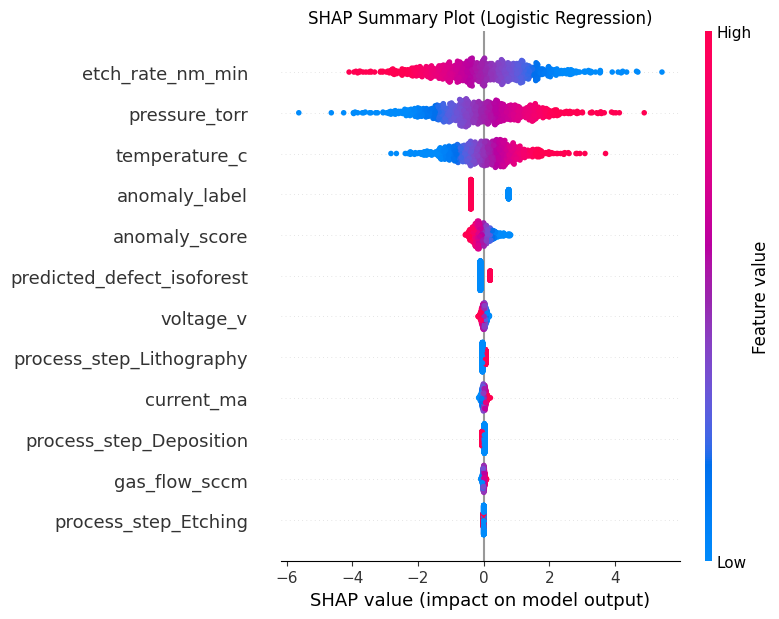

In [ ]:
import shap
import matplotlib.pyplot as plt

# 2. Initialize a SHAP Explainer object
# For Logistic Regression, we typically use LinearExplainer
explainer = shap.LinearExplainer(lr_model, X_train)

# 3. Calculate the SHAP values for the validation features X_val
shap_values = explainer.shap_values(X_val)

# 4. Generate and display a SHAP summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Logistic Regression)')
plt.tight_layout()
plt.show()

# For a more detailed plot showing impact and direction (often preferred for interpretation)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_val, show=False)
plt.title('SHAP Summary Plot (Logistic Regression)')
plt.tight_layout()
plt.show()
